In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
from datetime import datetime
import os
style.use('fast')
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score  
from statistics import mean

def ROC_PR_AUC_Curves(Values_real,Value_infered, number_genes, file_path_data, algorithm, color_ROC="indigo", color_PR= "springgreen", show_plot=False):
    """
        This functions returns the area under the ROC and PR curve 
        and plots the tpr vs fpr and the precision vs recall.
    """
    
    #ROC
    fpr, tpr, thresholds = roc_curve(Values_real, Value_infered)
    AUC_ROC = auc(fpr, tpr)
    
    
    #PR
    precision, recall, thresholds = precision_recall_curve(Values_real, Value_infered)
    AUC_PR = auc(recall, precision)
    
    if show_plot==True:
        
        plt.rc('xtick', labelsize=22)    
        plt.rc('ytick', labelsize=22)    
        plt.rcParams["font.family"] = "serif"
    
        plt.figure(figsize=(9,7))
        plt.plot([0, 1], [0, 1], 'k--',  lw=2.8)
        plt.plot(fpr, tpr, lw=2.8, color=color_ROC,label='Area = {:.3f}'.format(AUC_ROC))
        plt.fill_between(fpr, tpr,color=color_ROC, alpha=0.28)
        plt.xlabel('False positive rate',family="serif",fontsize = 26)
        plt.ylabel('True positive rate',family="serif",fontsize = 26)
        plt.title(f'ROC {number_genes} Genes, {algorithm}',family="serif",fontsize = 31)
        plt.legend(prop={'size':20, 'family':'serif'},loc='lower right')
        #plt.savefig(f"{file_path_data}/ROC_curve_Genes-{number_genes}.png", bbox_inches="tight", dpi=100 )
        
        plt.figure(figsize=(9,7))
        plt.plot([0, 1], [1, 0], 'k--',  lw=2.8)
        plt.plot(recall, precision, lw=2.8, color=color_PR,label='Area = {:.3f}'.format(AUC_PR))
        plt.fill_between(recall, precision,color=color_PR, alpha=0.28)
        plt.xlabel('Recall',family="serif",fontsize = 26)
        plt.ylabel('Precision',family="serif",fontsize = 26)
        plt.title(f'PRC {number_genes} Genes, {algorithm}',family="serif",fontsize = 31)
        plt.legend(prop={'size':20, 'family':'serif'},loc='lower right')
        #plt.savefig(f"{file_path_data}/PR_curve_Genes-{number_genes}.png", bbox_inches="tight", dpi=100 )
        
    
    return AUC_ROC, AUC_PR


In [25]:
file_path_results = "Computing_Performance_4_in_degree/"
try:
    os.mkdir(file_path_results)
except OSError as error:
    print(f"Folder {file_path_results} already created.")

header_list_dynGENIE3_rand = ["Cause Gene", "Effect Gene", "mean_importance"]
header_list = ["Cause Gene", "Effect Gene", "Value"]
gold_standard = {}
Nodes = [10, 20, 50, 100]
step = 10

AUROC_value_dynGENIE3_list = {}
AUPRC_value_dynGENIE3_list = {}

AUROC_value_SWING_list = {}
AUPRC_value_SWING_list = {}

AUROC_value_dynGENIE3_list_rand = {}
AUPRC_value_dynGENIE3_list_rand = {}

AUROC_value_dynGENIE3_list_crand = {}
AUPRC_value_dynGENIE3_list_crand = {}

AUROC_value_SWING_list_rand = {}
AUPRC_value_SWING_list_rand = {}

AUROC_value_SWING_list_crand = {}
AUPRC_value_SWING_list_crand = {}

AUROC_value_random_list = {}
AUPRC_value_random_list = {}

for nodes in Nodes:
    
    AUROC_value_dynGENIE3_list[f"AUROC_value_dynGENIE3_list_{nodes}genes"] = []
    AUPRC_value_dynGENIE3_list[f"AUPRC_value_dynGENIE3_list_{nodes}genes"] = []
    
    AUROC_value_SWING_list[f"AUROC_value_SWING_list_{nodes}genes"] = []
    AUPRC_value_SWING_list[f"AUPRC_value_SWING_list_{nodes}genes"] = []
    
    AUROC_value_dynGENIE3_list_rand[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"] = []
    AUPRC_value_dynGENIE3_list_rand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"] = []
    
    AUROC_value_SWING_list_rand[f"AUROC_value_SWING_list_{nodes}genes_rand"] = []
    AUPRC_value_SWING_list_rand[f"AUPRC_value_SWING_list_{nodes}genes_rand"] = []
    
    AUROC_value_dynGENIE3_list_crand[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"] = []
    AUPRC_value_dynGENIE3_list_crand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"] = []
    
    AUROC_value_SWING_list_crand[f"AUROC_value_SWING_list_{nodes}genes_crand"] = []
    AUPRC_value_SWING_list_crand[f"AUPRC_value_SWING_list_{nodes}genes_crand"] = []
    
    AUROC_value_random_list[f"AUROC_value_random_list_{nodes}genes"] = []
    AUPRC_value_random_list[f"AUPRC_value_random_list_{nodes}genes"] = []
    
    for instance in range(100):
        
        instance = instance + 1
        
        mean_importance_file_SWING = pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_SWING_{instance}.tsv", sep ="\t")
        if (nodes == 10) | (nodes == 20):
            mean_importance_file_dynGENIE3= pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}", sep ="\t").sort_values(by=["Cause Gene", "Effect Gene"])
        else:
            mean_importance_file_dynGENIE3= pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks/mean_importance_dynGENIE3_{instance}.tsv", sep ="\t", names = ["Cause Gene", "Effect Gene", "mean_importance"]).sort_values(by=["Cause Gene", "Effect Gene"])
        
        mean_importance_file_SWING_rand = pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_SWING_{instance}_rand.tsv", sep ="\t")
        mean_importance_file_dynGENIE3_rand = pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_rand/mean_importance_dynGENIE3_{instance}_rand.tsv", sep ="\t", names = header_list_dynGENIE3_rand).sort_values(by=["Cause Gene", "Effect Gene"])
        
        mean_importance_file_SWING_crand = pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_SWING_{instance}_crand.tsv", sep ="\t")
        mean_importance_file_dynGENIE3_crand = pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Results_{nodes}genes_100insilico_networks_crand/mean_importance_dynGENIE3_{instance}_crand.tsv", sep ="\t", names = header_list_dynGENIE3_rand).sort_values(by=["Cause Gene", "Effect Gene"])
    
        rank_SWING = mean_importance_file_SWING["mean_importance"]
        rank_dynGENIE3 = mean_importance_file_dynGENIE3["mean_importance"]
        
        rank_SWING_rand = mean_importance_file_SWING_rand["mean_importance"]
        rank_dynGENIE3_rand = mean_importance_file_dynGENIE3_rand["mean_importance"]
        
        rank_SWING_crand = mean_importance_file_SWING_crand["mean_importance"]
        rank_dynGENIE3_crand = mean_importance_file_dynGENIE3_crand["mean_importance"]
        
        if (nodes == 10) | (nodes == 20):
            gold_standard = pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Networks_in_out_degree_4_num_nodes_{nodes}/in_and_out_degree_4_num_nodes_{nodes}_case_{instance}/goldstandard_signed_{instance}_goldstandard.tsv", sep="\t", names= header_list)
        else:
            gold_standard = pd.read_csv(f"networks_in_out_degree_4_num_nodes_{nodes}/Networks_in_out_degree_4_num_nodes_{nodes}/gold_standard/gold_standard_{instance}.tsv", sep="\t", names= header_list)
                
        gold_standard = gold_standard.sort_values(by=["Cause Gene", "Effect Gene"])
        
        AUROC_value_dynGENIE3, AUPRC_value_dynGENIE3 = ROC_PR_AUC_Curves(gold_standard["Value"], rank_dynGENIE3, nodes, "Nothing", f"dynGENIE3 Run {instance}", show_plot=False)
        AUROC_value_SWING, AUPRC_value_SWING = ROC_PR_AUC_Curves(gold_standard["Value"], rank_SWING , nodes, "Nothing", f"SWING Run {instance}", show_plot=False)
        
        AUROC_value_dynGENIE3_rand, AUPRC_value_dynGENIE3_rand = ROC_PR_AUC_Curves(gold_standard["Value"], rank_dynGENIE3_rand, nodes, "Nothing", f"dynGENIE3 Run {instance}", show_plot=False)
        AUROC_value_SWING_rand, AUPRC_value_SWING_rand = ROC_PR_AUC_Curves(gold_standard["Value"], rank_SWING_rand , nodes, "Nothing", f"SWING Run {instance}", show_plot=False)
        
        AUROC_value_dynGENIE3_crand, AUPRC_value_dynGENIE3_crand = ROC_PR_AUC_Curves(gold_standard["Value"], rank_dynGENIE3_crand, nodes, "Nothing", f"dynGENIE3 Run {instance}", show_plot=False)
        AUROC_value_SWING_crand, AUPRC_value_SWING_crand = ROC_PR_AUC_Curves(gold_standard["Value"], rank_SWING_crand , nodes, "Nothing", f"SWING Run {instance}", show_plot=False)
        
        AUROC_value_random, AUPRC_value_random = ROC_PR_AUC_Curves(gold_standard["Value"], np.random.rand(1,len(rank_SWING))[0].tolist() , nodes, "Nothing", f"Random Run {instance}", show_plot=False)
        
        print(f"AUROC SWING value Run {instance}: ", AUROC_value_SWING)
        print(f"AUPRC SWING value Run {instance}: ", AUPRC_value_SWING)
        
        print(f"AUROC dynGENIE3 value Run {instance}: ", AUROC_value_dynGENIE3)
        print(f"AUPRC dynGENIE3 value Run {instance}: ", AUPRC_value_dynGENIE3)
        
        print(f"AUROC SWING rand value Run {instance}: ", AUROC_value_SWING_rand)
        print(f"AUPRC SWING rand value Run {instance}: ", AUPRC_value_SWING_rand)
        
        print(f"AUROC dynGENIE3 rand value Run {instance}: ", AUROC_value_dynGENIE3_rand)
        print(f"AUPRC dynGENIE3 rand value Run {instance}: ", AUPRC_value_dynGENIE3_rand)
        
        print(f"AUROC SWING crand value Run {instance}: ", AUROC_value_SWING_crand)
        print(f"AUPRC SWING crand value Run {instance}: ", AUPRC_value_SWING_crand)
        
        print(f"AUROC dynGENIE3 crand value Run {instance}: ", AUROC_value_dynGENIE3_crand)
        print(f"AUPRC dynGENIE3 crand value Run {instance}: ", AUPRC_value_dynGENIE3_crand)
        
        print(f"AUROC random value Run {instance}: ", AUROC_value_random)
        print(f"AUPRC random value Run {instance}: ", AUROC_value_random)
        
        AUROC_value_SWING_list[f"AUROC_value_SWING_list_{nodes}genes"].append(AUROC_value_SWING)
        AUPRC_value_SWING_list[f"AUPRC_value_SWING_list_{nodes}genes"].append(AUPRC_value_SWING)
        
        AUROC_value_dynGENIE3_list[f"AUROC_value_dynGENIE3_list_{nodes}genes"].append(AUROC_value_dynGENIE3)
        AUPRC_value_dynGENIE3_list[f"AUPRC_value_dynGENIE3_list_{nodes}genes"].append(AUPRC_value_dynGENIE3)
        
        AUROC_value_SWING_list_rand[f"AUROC_value_SWING_list_{nodes}genes_rand"].append(AUROC_value_SWING_rand)
        AUPRC_value_SWING_list_rand[f"AUPRC_value_SWING_list_{nodes}genes_rand"].append(AUPRC_value_SWING_rand)
        
        AUROC_value_dynGENIE3_list_rand[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"].append(AUROC_value_dynGENIE3_rand)
        AUPRC_value_dynGENIE3_list_rand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"].append(AUPRC_value_dynGENIE3_rand)
        
        
        AUROC_value_SWING_list_crand[f"AUROC_value_SWING_list_{nodes}genes_crand"].append(AUROC_value_SWING_crand)
        AUPRC_value_SWING_list_crand[f"AUPRC_value_SWING_list_{nodes}genes_crand"].append(AUPRC_value_SWING_crand)
        
        AUROC_value_dynGENIE3_list_crand[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"].append(AUROC_value_dynGENIE3_crand)
        AUPRC_value_dynGENIE3_list_crand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"].append(AUPRC_value_dynGENIE3_crand)
        
        
        AUROC_value_random_list[f"AUROC_value_random_list_{nodes}genes"].append(AUROC_value_random)
        AUPRC_value_random_list[f"AUPRC_value_random_list_{nodes}genes"].append(AUPRC_value_random)
    
    AUROC_file_SWING = open(f"{file_path_results}/AUROC_results_{nodes}genes_SWING.txt", "w")
    AUROC_file_dynGENIE3 = open(f"{file_path_results}/AUROC_results_{nodes}genes_dynGENIE3.txt", "w")
    AUROC_file_SWING_rand = open(f"{file_path_results}/AUROC_results_{nodes}genes_SWING_rand.txt", "w")
    AUROC_file_dynGENIE3_rand = open(f"{file_path_results}/AUROC_results_{nodes}genes_dynGENIE3_rand.txt", "w")
    AUROC_file_SWING_crand = open(f"{file_path_results}/AUROC_results_{nodes}genes_SWING_crand.txt", "w")
    AUROC_file_dynGENIE3_crand = open(f"{file_path_results}/AUROC_results_{nodes}genes_dynGENIE3_crand.txt", "w")
    AUROC_file_random = open(f"{file_path_results}/AUROC_results_{nodes}genes_random.txt", "w")
    
    AUPRC_file_SWING = open(f"{file_path_results}/AUPRC_results_{nodes}genes_SWING.txt", "w")
    AUPRC_file_dynGENIE3 = open(f"{file_path_results}/AUPRC_results_{nodes}genes_dynGENIE3.txt", "w")
    AUPRC_file_SWING_rand = open(f"{file_path_results}/AUPRC_results_{nodes}genes_SWING_rand.txt", "w")
    AUPRC_file_dynGENIE3_rand = open(f"{file_path_results}/AUPRC_results_{nodes}genes_dynGENIE3_rand.txt", "w")
    AUPRC_file_SWING_crand = open(f"{file_path_results}/AUPRC_results_{nodes}genes_SWING_crand.txt", "w")
    AUPRC_file_dynGENIE3_crand = open(f"{file_path_results}/AUPRC_results_{nodes}genes_dynGENIE3_crand.txt", "w")
    AUPRC_file_random = open(f"{file_path_results}/AUPRC_results_{nodes}genes_random.txt", "w")
    
    for element in AUROC_value_SWING_list[f"AUROC_value_SWING_list_{nodes}genes"]:
        AUROC_file_SWING.write(str(element) + "\n")
    AUROC_file_SWING.close()
    
    for element in AUROC_value_dynGENIE3_list[f"AUROC_value_dynGENIE3_list_{nodes}genes"]:
        AUROC_file_dynGENIE3.write(str(element) + "\n")
    AUROC_file_dynGENIE3.close()
    
    for element in AUROC_value_SWING_list_rand[f"AUROC_value_SWING_list_{nodes}genes_rand"]:
        AUROC_file_SWING_rand.write(str(element) + "\n")
    AUROC_file_SWING_rand.close()
    
    for element in AUROC_value_SWING_list_crand[f"AUROC_value_SWING_list_{nodes}genes_crand"]:
        AUROC_file_SWING_crand.write(str(element) + "\n")
    AUROC_file_SWING_crand.close()
    
    for element in AUROC_value_dynGENIE3_list_rand[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"]:
        AUROC_file_dynGENIE3_rand.write(str(element) + "\n")
    AUROC_file_dynGENIE3_rand.close()
    
    for element in AUROC_value_dynGENIE3_list_crand[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"]:
        AUROC_file_dynGENIE3_crand.write(str(element) + "\n")
    AUROC_file_dynGENIE3_crand.close()
    
    for element in AUROC_value_random_list[f"AUROC_value_random_list_{nodes}genes"]:
        AUROC_file_random.write(str(element) + "\n")
    AUROC_file_random.close()
    
    for element in AUPRC_value_SWING_list[f"AUPRC_value_SWING_list_{nodes}genes"]:
        AUPRC_file_SWING.write(str(element) + "\n")
    AUPRC_file_SWING.close()
    
    for element in AUPRC_value_dynGENIE3_list[f"AUPRC_value_dynGENIE3_list_{nodes}genes"]:
        AUPRC_file_dynGENIE3.write(str(element) + "\n")
    AUPRC_file_dynGENIE3.close()
    
    for element in AUPRC_value_SWING_list_rand[f"AUPRC_value_SWING_list_{nodes}genes_rand"]:
        AUPRC_file_SWING_rand.write(str(element) + "\n")
    AUPRC_file_SWING_rand.close()
    
    for element in AUPRC_value_SWING_list_crand[f"AUPRC_value_SWING_list_{nodes}genes_crand"]:
        AUPRC_file_SWING_crand.write(str(element) + "\n")
    AUPRC_file_SWING_crand.close()
    
    for element in AUPRC_value_dynGENIE3_list_rand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"]:
        AUPRC_file_dynGENIE3_rand.write(str(element) + "\n")
    AUPRC_file_dynGENIE3_rand.close()
    
    for element in AUPRC_value_dynGENIE3_list_crand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"]:
        AUPRC_file_dynGENIE3_crand.write(str(element) + "\n")
    AUPRC_file_dynGENIE3_crand.close()
    
    for element in AUPRC_value_random_list[f"AUPRC_value_random_list_{nodes}genes"]:
        AUPRC_file_random.write(str(element) + "\n")
    AUPRC_file_random.close()

Folder Computing_Performance_4_in_degree/ already created.
AUROC SWING value Run 1:  0.538
AUPRC SWING value Run 1:  0.5300426408189542
AUROC dynGENIE3 value Run 1:  0.4785
AUPRC dynGENIE3 value Run 1:  0.4359812732726367
AUROC SWING rand value Run 1:  0.4985
AUPRC SWING rand value Run 1:  0.4502087558380102
AUROC dynGENIE3 rand value Run 1:  0.3805
AUPRC dynGENIE3 rand value Run 1:  0.3635599249039001
AUROC SWING crand value Run 1:  0.5115
AUPRC SWING crand value Run 1:  0.4665502777588654
AUROC dynGENIE3 crand value Run 1:  0.4595
AUPRC dynGENIE3 crand value Run 1:  0.3945155454244874
AUROC random value Run 1:  0.4605
AUPRC random value Run 1:  0.4605
AUROC SWING value Run 2:  0.595
AUPRC SWING value Run 2:  0.5728325804345007
AUROC dynGENIE3 value Run 2:  0.6415
AUPRC dynGENIE3 value Run 2:  0.5646642768800243
AUROC SWING rand value Run 2:  0.518
AUPRC SWING rand value Run 2:  0.43497280045523823
AUROC dynGENIE3 rand value Run 2:  0.5085
AUPRC dynGENIE3 rand value Run 2:  0.46199795

AUROC SWING value Run 14:  0.6804999999999999
AUPRC SWING value Run 14:  0.6541760257575373
AUROC dynGENIE3 value Run 14:  0.5385
AUPRC dynGENIE3 value Run 14:  0.5150506004673179
AUROC SWING rand value Run 14:  0.5984999999999999
AUPRC SWING rand value Run 14:  0.541644779654616
AUROC dynGENIE3 rand value Run 14:  0.5934999999999999
AUPRC dynGENIE3 rand value Run 14:  0.5517498763811745
AUROC SWING crand value Run 14:  0.5795
AUPRC SWING crand value Run 14:  0.5501819305304371
AUROC dynGENIE3 crand value Run 14:  0.496
AUPRC dynGENIE3 crand value Run 14:  0.4656375747293092
AUROC random value Run 14:  0.514
AUPRC random value Run 14:  0.514
AUROC SWING value Run 15:  0.6559999999999999
AUPRC SWING value Run 15:  0.620424819801074
AUROC dynGENIE3 value Run 15:  0.683
AUPRC dynGENIE3 value Run 15:  0.5959737118830731
AUROC SWING rand value Run 15:  0.5825
AUPRC SWING rand value Run 15:  0.5192928498117778
AUROC dynGENIE3 rand value Run 15:  0.5155000000000001
AUPRC dynGENIE3 rand value 

AUROC SWING value Run 29:  0.6180000000000001
AUPRC SWING value Run 29:  0.6297345731503438
AUROC dynGENIE3 value Run 29:  0.548
AUPRC dynGENIE3 value Run 29:  0.5083473002663117
AUROC SWING rand value Run 29:  0.552
AUPRC SWING rand value Run 29:  0.5346209589110857
AUROC dynGENIE3 rand value Run 29:  0.513
AUPRC dynGENIE3 rand value Run 29:  0.46864097412149847
AUROC SWING crand value Run 29:  0.438
AUPRC SWING crand value Run 29:  0.46294126703858796
AUROC dynGENIE3 crand value Run 29:  0.5115000000000001
AUPRC dynGENIE3 crand value Run 29:  0.42540488145771993
AUROC random value Run 29:  0.5075
AUPRC random value Run 29:  0.5075
AUROC SWING value Run 30:  0.5325
AUPRC SWING value Run 30:  0.5117702507596894
AUROC dynGENIE3 value Run 30:  0.537
AUPRC dynGENIE3 value Run 30:  0.5260916183013241
AUROC SWING rand value Run 30:  0.4685
AUPRC SWING rand value Run 30:  0.4073991063226279
AUROC dynGENIE3 rand value Run 30:  0.3805
AUPRC dynGENIE3 rand value Run 30:  0.3678418382728126
AURO

AUROC dynGENIE3 value Run 42:  0.625
AUPRC dynGENIE3 value Run 42:  0.545913488374211
AUROC SWING rand value Run 42:  0.588
AUPRC SWING rand value Run 42:  0.5042693763630643
AUROC dynGENIE3 rand value Run 42:  0.5505
AUPRC dynGENIE3 rand value Run 42:  0.47642252720968936
AUROC SWING crand value Run 42:  0.5954999999999999
AUPRC SWING crand value Run 42:  0.5359812580439318
AUROC dynGENIE3 crand value Run 42:  0.5555
AUPRC dynGENIE3 crand value Run 42:  0.5060347820461868
AUROC random value Run 42:  0.3325
AUPRC random value Run 42:  0.3325
AUROC SWING value Run 43:  0.5765
AUPRC SWING value Run 43:  0.6030254509904716
AUROC dynGENIE3 value Run 43:  0.616
AUPRC dynGENIE3 value Run 43:  0.5972438731676618
AUROC SWING rand value Run 43:  0.515
AUPRC SWING rand value Run 43:  0.4781285780543189
AUROC dynGENIE3 rand value Run 43:  0.621
AUPRC dynGENIE3 rand value Run 43:  0.5372889373987049
AUROC SWING crand value Run 43:  0.5465
AUPRC SWING crand value Run 43:  0.5574516963320627
AUROC d

AUROC SWING value Run 56:  0.672
AUPRC SWING value Run 56:  0.6446420275222456
AUROC dynGENIE3 value Run 56:  0.713
AUPRC dynGENIE3 value Run 56:  0.6673888044582097
AUROC SWING rand value Run 56:  0.5465
AUPRC SWING rand value Run 56:  0.4723594814951364
AUROC dynGENIE3 rand value Run 56:  0.447
AUPRC dynGENIE3 rand value Run 56:  0.4141926476458714
AUROC SWING crand value Run 56:  0.539
AUPRC SWING crand value Run 56:  0.5029595783828604
AUROC dynGENIE3 crand value Run 56:  0.472
AUPRC dynGENIE3 crand value Run 56:  0.43485304687978465
AUROC random value Run 56:  0.549
AUPRC random value Run 56:  0.549
AUROC SWING value Run 57:  0.6715
AUPRC SWING value Run 57:  0.5954863516883353
AUROC dynGENIE3 value Run 57:  0.6335
AUPRC dynGENIE3 value Run 57:  0.6047155587847811
AUROC SWING rand value Run 57:  0.6120000000000001
AUPRC SWING rand value Run 57:  0.555890996701603
AUROC dynGENIE3 rand value Run 57:  0.5915
AUPRC dynGENIE3 rand value Run 57:  0.5164034763207449
AUROC SWING crand val

...

AUROC SWING value Run 43:  0.6613802631578948
AUPRC SWING value Run 43:  0.15070405363852687
AUROC dynGENIE3 value Run 43:  0.6377481578947368
AUPRC dynGENIE3 value Run 43:  0.11744032419065076
AUROC SWING rand value Run 43:  0.6027947368421054
AUPRC SWING rand value Run 43:  0.05831265034254317
AUROC dynGENIE3 rand value Run 43:  0.5849476315789474
AUPRC dynGENIE3 rand value Run 43:  0.056311405078513226
AUROC SWING crand value Run 43:  0.5974105263157894
AUPRC SWING crand value Run 43:  0.06154175680180642
AUROC dynGENIE3 crand value Run 43:  0.5846418421052632
AUPRC dynGENIE3 crand value Run 43:  0.05258765601941941
AUROC random value Run 43:  0.5109013157894737
AUPRC random value Run 43:  0.5109013157894737
AUROC SWING value Run 44:  0.6287321052631579
AUPRC SWING value Run 44:  0.11636463224857492
AUROC dynGENIE3 value Run 44:  0.5944602631578947
AUPRC dynGENIE3 value Run 44:  0.07604573495495541
AUROC SWING rand value Run 44:  0.5802378947368421
AUPRC SWING rand value Run 44:  0.

AUROC SWING value Run 55:  0.6651663157894737
AUPRC SWING value Run 55:  0.14429875115179974
AUROC dynGENIE3 value Run 55:  0.6235992105263158
AUPRC dynGENIE3 value Run 55:  0.1064377376768808
AUROC SWING rand value Run 55:  0.590471052631579
AUPRC SWING rand value Run 55:  0.06073156477266094
AUROC dynGENIE3 rand value Run 55:  0.5629385526315789
AUPRC dynGENIE3 rand value Run 55:  0.058939937361341184
AUROC SWING crand value Run 55:  0.5973865789473685
AUPRC SWING crand value Run 55:  0.06116575165701097
AUROC dynGENIE3 crand value Run 55:  0.562126052631579
AUPRC dynGENIE3 crand value Run 55:  0.05557441516277937
AUROC random value Run 55:  0.4737189473684211
AUPRC random value Run 55:  0.4737189473684211
AUROC SWING value Run 56:  0.6735102631578946
AUPRC SWING value Run 56:  0.14973924362544555
AUROC dynGENIE3 value Run 56:  0.6412713157894736
AUPRC dynGENIE3 value Run 56:  0.10731035540136458
AUROC SWING rand value Run 56:  0.6069744736842105
AUPRC SWING rand value Run 56:  0.060

AUROC SWING value Run 67:  0.6374828947368422
AUPRC SWING value Run 67:  0.10635016474187313
AUROC dynGENIE3 value Run 67:  0.6082038157894737
AUPRC dynGENIE3 value Run 67:  0.07504676897676398
AUROC SWING rand value Run 67:  0.5780071052631579
AUPRC SWING rand value Run 67:  0.052056679394168595
AUROC dynGENIE3 rand value Run 67:  0.5661778947368421
AUPRC dynGENIE3 rand value Run 67:  0.04921750150057532
AUROC SWING crand value Run 67:  0.5933371052631579
AUPRC SWING crand value Run 67:  0.056539039655218004
AUROC dynGENIE3 crand value Run 67:  0.5640835526315789
AUPRC dynGENIE3 crand value Run 67:  0.04966410595664002
AUROC random value Run 67:  0.5051189473684211
AUPRC random value Run 67:  0.5051189473684211
AUROC SWING value Run 68:  0.670768947368421
AUPRC SWING value Run 68:  0.16294104669634837
AUROC dynGENIE3 value Run 68:  0.6339944736842105
AUPRC dynGENIE3 value Run 68:  0.12541439983208158
AUROC SWING rand value Run 68:  0.5971449999999999
AUPRC SWING rand value Run 68:  0.

AUROC SWING value Run 80:  0.6731805263157895
AUPRC SWING value Run 80:  0.16107045724752841
AUROC dynGENIE3 value Run 80:  0.6235844736842104
AUPRC dynGENIE3 value Run 80:  0.08669535090079847
AUROC SWING rand value Run 80:  0.6118076315789474
AUPRC SWING rand value Run 80:  0.066589806811447
AUROC dynGENIE3 rand value Run 80:  0.5996513157894736
AUPRC dynGENIE3 rand value Run 80:  0.06064261111907291
AUROC SWING crand value Run 80:  0.5946834210526316
AUPRC SWING crand value Run 80:  0.06162136371404617
AUROC dynGENIE3 crand value Run 80:  0.5695325
AUPRC dynGENIE3 crand value Run 80:  0.05637467052548779
AUROC random value Run 80:  0.4945413157894737
AUPRC random value Run 80:  0.4945413157894737
AUROC SWING value Run 81:  0.6493007894736842
AUPRC SWING value Run 81:  0.1272010440726678
AUROC dynGENIE3 value Run 81:  0.6051601315789473
AUPRC dynGENIE3 value Run 81:  0.0830057163678449
AUROC SWING rand value Run 81:  0.5582663157894736
AUPRC SWING rand value Run 81:  0.05125568699383

AUROC SWING value Run 92:  0.6849707894736842
AUPRC SWING value Run 92:  0.15674309325697355
AUROC dynGENIE3 value Run 92:  0.6278844736842105
AUPRC dynGENIE3 value Run 92:  0.09365069018299924
AUROC SWING rand value Run 92:  0.6033100000000001
AUPRC SWING rand value Run 92:  0.06644209183680819
AUROC dynGENIE3 rand value Run 92:  0.5741615789473684
AUPRC dynGENIE3 rand value Run 92:  0.057270639990843426
AUROC SWING crand value Run 92:  0.6107281578947369
AUPRC SWING crand value Run 92:  0.06523474664738181
AUROC dynGENIE3 crand value Run 92:  0.5844607894736842
AUPRC dynGENIE3 crand value Run 92:  0.056111799552814284
AUROC random value Run 92:  0.4966807894736842
AUPRC random value Run 92:  0.4966807894736842
AUROC SWING value Run 93:  0.659943947368421
AUPRC SWING value Run 93:  0.13729203012847788
AUROC dynGENIE3 value Run 93:  0.6100867105263159
AUPRC dynGENIE3 value Run 93:  0.09732554192019971
AUROC SWING rand value Run 93:  0.565133947368421
AUPRC SWING rand value Run 93:  0.0

# Bar plot: Averaging over all the ROC and PRC values

# AUROC

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

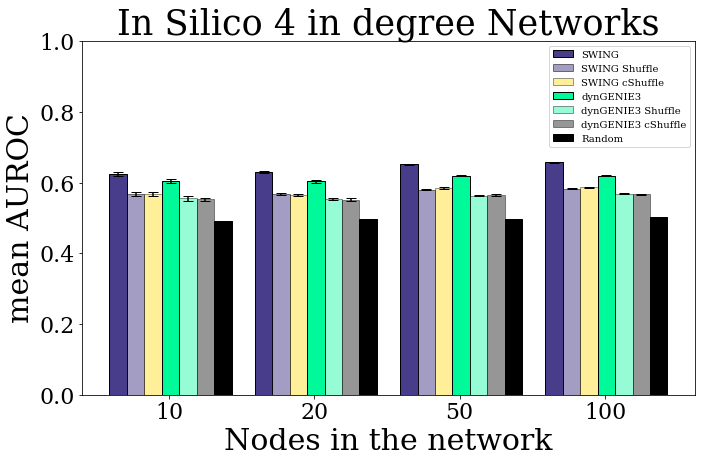

In [35]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rcParams["font.family"] = "serif"

SWING = [mean(AUROC_value_SWING_list[f"AUROC_value_SWING_list_{nodes}genes"]) for nodes in Nodes]
SWING_std = [np.std(AUROC_value_SWING_list[f"AUROC_value_SWING_list_{nodes}genes"])/10 for nodes in Nodes]

SWING_rand = [mean(AUROC_value_SWING_list_rand[f"AUROC_value_SWING_list_{nodes}genes_rand"]) for nodes in Nodes]
SWING_rand_std = [np.std(AUROC_value_SWING_list_rand[f"AUROC_value_SWING_list_{nodes}genes_rand"])/10 for nodes in Nodes]

SWING_crand = [mean(AUROC_value_SWING_list_crand[f"AUROC_value_SWING_list_{nodes}genes_crand"]) for nodes in Nodes]
SWING_crand_std = [np.std(AUROC_value_SWING_list_crand[f"AUROC_value_SWING_list_{nodes}genes_crand"])/10 for nodes in Nodes]

dynGENIE3 = [mean(AUROC_value_dynGENIE3_list[f"AUROC_value_dynGENIE3_list_{nodes}genes"]) for nodes in Nodes]
dynGENIE3_std = [np.std(AUROC_value_dynGENIE3_list[f"AUROC_value_dynGENIE3_list_{nodes}genes"])/10 for nodes in Nodes]

dynGENIE3_rand = [mean(AUROC_value_dynGENIE3_list_rand[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"]) for nodes in Nodes]
dynGENIE3_rand_std = [np.std(AUROC_value_dynGENIE3_list_rand[f"AUROC_value_dynGENIE3_list_{nodes}genes_rand"])/10 for nodes in Nodes]

dynGENIE3_crand = [mean(AUROC_value_dynGENIE3_list_crand[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"]) for nodes in Nodes]
dynGENIE3_crand_std = [np.std(AUROC_value_dynGENIE3_list_crand[f"AUROC_value_dynGENIE3_list_{nodes}genes_crand"])/10 for nodes in Nodes]

random = [mean(AUROC_value_random_list[f"AUROC_value_random_list_{nodes}genes"]) for nodes in Nodes]
random_std = [np.std(AUROC_value_random_list[f"AUROC_value_random_list_{nodes}genes"])/10 for nodes in Nodes]

labels = ["10", "20", "50", "100"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.rc('xtick', labelsize=22)    
plt.rc('ytick', labelsize=22)    
plt.rcParams["font.family"] = "serif"
    
plt.figure(figsize=(11,6.5))

# Make the plot
plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='#FFD700', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumspringgreen', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='k', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')

plt.ylabel('mean AUROC', family = 'serif',fontsize = 30)
plt.xlabel('Nodes in the network', family = 'serif',fontsize = 30)
#FFD700
plt.xticks([r + barWidth + 0.23 for r in range(len(SWING))], ["10", "20", "50", "100"])
plt.title("In Silico 4 in degree Networks", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2.png", bbox_inches="tight", dpi=100 )

# AUPRC

(0.0, 1.0)

<Figure size 576x360 with 0 Axes>

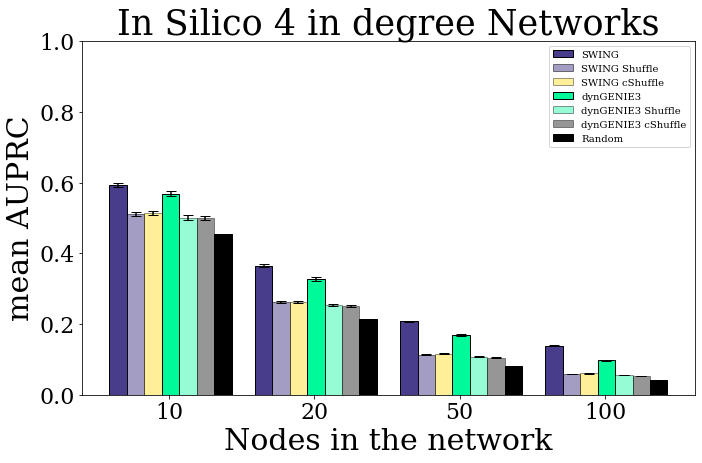

In [37]:
figure = plt.figure(figsize=(8,5))
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rcParams["font.family"] = "serif"

SWING = [mean(AUPRC_value_SWING_list[f"AUPRC_value_SWING_list_{nodes}genes"]) for nodes in Nodes]
SWING_std = [np.std(AUPRC_value_SWING_list[f"AUPRC_value_SWING_list_{nodes}genes"])/10 for nodes in Nodes]

SWING_rand = [mean(AUPRC_value_SWING_list_rand[f"AUPRC_value_SWING_list_{nodes}genes_rand"]) for nodes in Nodes]
SWING_rand_std = [np.std(AUPRC_value_SWING_list_rand[f"AUPRC_value_SWING_list_{nodes}genes_rand"])/10 for nodes in Nodes]

SWING_crand = [mean(AUPRC_value_SWING_list_crand[f"AUPRC_value_SWING_list_{nodes}genes_crand"]) for nodes in Nodes]
SWING_crand_std = [np.std(AUPRC_value_SWING_list_crand[f"AUPRC_value_SWING_list_{nodes}genes_crand"])/10 for nodes in Nodes]

dynGENIE3 = [mean(AUPRC_value_dynGENIE3_list[f"AUPRC_value_dynGENIE3_list_{nodes}genes"]) for nodes in Nodes]
dynGENIE3_std = [np.std(AUPRC_value_dynGENIE3_list[f"AUPRC_value_dynGENIE3_list_{nodes}genes"])/10 for nodes in Nodes]

dynGENIE3_rand = [mean(AUPRC_value_dynGENIE3_list_rand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"]) for nodes in Nodes]
dynGENIE3_rand_std = [np.std(AUPRC_value_dynGENIE3_list_rand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_rand"])/10 for nodes in Nodes]

dynGENIE3_crand = [mean(AUPRC_value_dynGENIE3_list_crand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"]) for nodes in Nodes]
dynGENIE3_crand_std = [np.std(AUPRC_value_dynGENIE3_list_crand[f"AUPRC_value_dynGENIE3_list_{nodes}genes_crand"])/10 for nodes in Nodes]

random = [mean(AUPRC_value_random_list[f"AUPRC_value_random_list_{nodes}genes"]) for nodes in Nodes]
random_std = [np.std(AUPRC_value_random_list[f"AUPRC_value_random_list_{nodes}genes"])/10 for nodes in Nodes]

labels = ["10", "20", "50", "100"]
barWidth = 0.12

# Set position of bar on X axis
br1 = np.arange(len(SWING))
br2 = [x + barWidth for x in br1]
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
br6 = [x + barWidth for x in br5]
br7 = [x + barWidth for x in br6]

plt.rc('xtick', labelsize=22)    
plt.rc('ytick', labelsize=22)    
plt.rcParams["font.family"] = "serif"
    
plt.figure(figsize=(11,6.5))

# Make the plot
plt.bar(br1, SWING, yerr=SWING_std,capsize=5, align='center', color='darkslateblue', width= barWidth, edgecolor= 'k', label='SWING')
plt.bar(br2, SWING_rand, yerr=SWING_rand_std,capsize=5, align='center', color='darkslateblue', alpha = 0.5, width= barWidth, edgecolor= 'k', label='SWING Shuffle')
plt.bar(br3, SWING_crand, yerr=SWING_crand_std,capsize=5, align='center', color='#FFD700', alpha = 0.4, width= barWidth, edgecolor= 'k', label='SWING cShuffle')
plt.bar(br4, dynGENIE3, yerr=dynGENIE3_std,capsize=5, align='center', color='mediumspringgreen', alpha = 1,width= barWidth, edgecolor= 'k', label='dynGENIE3')
plt.bar(br5, dynGENIE3_rand, yerr=dynGENIE3_rand_std,capsize=5, align='center', color='mediumspringgreen', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 Shuffle')
plt.bar(br6, dynGENIE3_crand, yerr=dynGENIE3_crand_std,capsize=5, align='center', color='k', alpha = 0.41,width= barWidth, edgecolor= 'k', label='dynGENIE3 cShuffle')
plt.bar(br7, random, color='k', alpha = 1,width= barWidth, edgecolor= 'k', label='Random')

plt.ylabel('mean AUPRC', family = 'serif',fontsize = 30)
plt.xlabel('Nodes in the network', family = 'serif',fontsize = 30)
#FFD700
plt.xticks([r + barWidth + 0.23 for r in range(len(SWING))], ["10", "20", "50", "100"])
plt.title("In Silico 4 in degree Networks", fontsize = 35)
plt.legend(prop={"size":10})
plt.ylim(0,1)
#plt.grid(linewidth=0.3)
#plt.savefig(f"C:/Users/ivana/OneDrive/Desktop/Internship New Folder/Results/In_degree_Results/ROC_in_degree_2.png", bbox_inches="tight", dpi=100 )